# Final project - Computer Vision

1. Apply atleast 6 transformations to an image dataset of your choice.
2. Train a CNN model using Pytorch to classify the images of CIFAR-10 dataset (from torchvision.datasets).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import time

from sklearn.metrics import confusion_matrix

import torch
import torchvision
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim

In [2]:
from torchvision import datasets

data_path = './datasets/'

cifar10 =  datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

100%|██████████| 170M/170M [00:27<00:00, 6.15MB/s] 


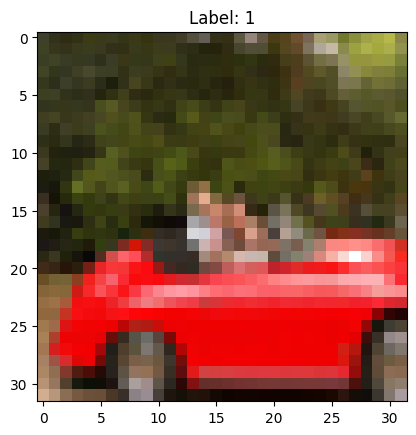

In [3]:
img, label = cifar10[99]
plt.imshow(img)
plt.title(f'Label: {label}')
plt.show()

In [4]:
def plot_images(original, transformed):
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(transformed)
    plt.title('Transformed Image')
    plt.axis('off')
    plt.show()

## Exercise 1 - Image Transformations

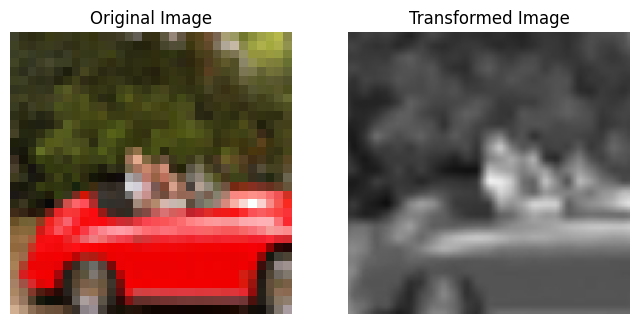

In [7]:
transforms = v2.Compose([
    v2.Resize((128, 128)),  # Resize to larger size first
    v2.RandomCrop(size=(100, 100)), # Crop section is random
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.Grayscale(num_output_channels=3),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToPILImage(),
])
cropped_image = transforms(img)
plot_images(img, cropped_image)

## Excercise 2 - CNN on CIFAR-10

### Data exploration and visualization

In [10]:
print(f'Classes in CIFAR-10: {cifar10.classes}')
print(f'Number of training images: {len(cifar10)}')
print(f'Number of validation images: {len(cifar10_val)}')
print(f'Image size: {cifar10[0][0].size}')

Classes in CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of training images: 50000
Number of validation images: 10000
Image size: (32, 32)


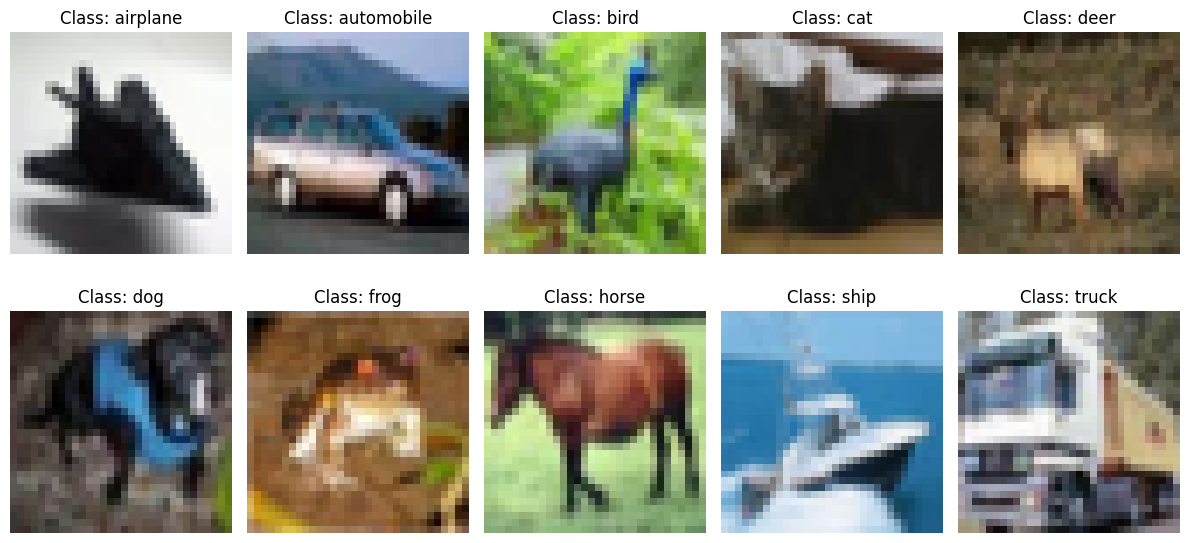

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
class_seen = set()
for img, label in cifar10:
    if label not in class_seen:
        ax = axes[label // 5, label % 5]
        ax.imshow(img)
        ax.set_title(f'Class: {cifar10.classes[label]}')
        ax.axis('off')
        class_seen.add(label)
    if len(class_seen) == 10:
        break
plt.tight_layout()
plt.show()

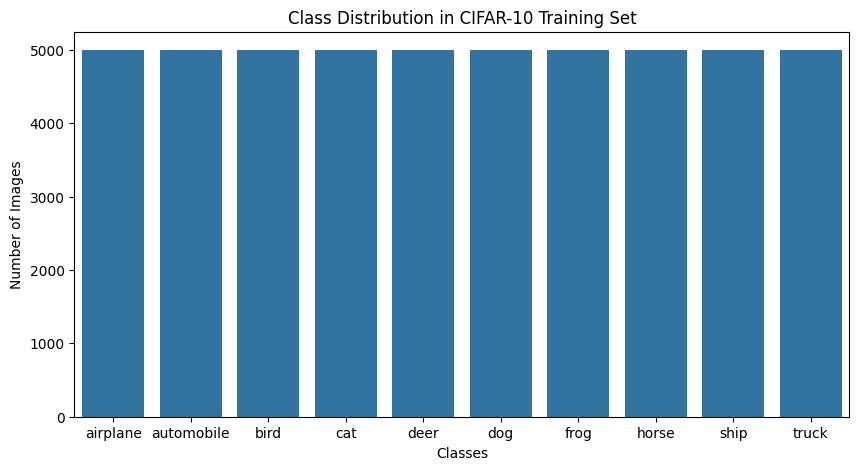

In [14]:
labels = [label for _, label in cifar10]
plt.figure(figsize=(10, 5))
sns.countplot(x=labels)
plt.xticks(ticks=range(10), labels=cifar10.classes)
plt.title('Class Distribution in CIFAR-10 Training Set')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()

The dataset contains 10 classes with 6000 images per class. There are 50000 training images and 10000 test images. Each image is of size 32x32 pixels with 3 color channels (RGB).

### Normalization and Data Augmentation

In [16]:
transforms_train = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

transforms_val = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

### Dataloader and dataset

In [17]:
train_dataset = datasets.CIFAR10(data_path, train=True, download=True, transform=transforms_train)
val_dataset = datasets.CIFAR10(data_path, train=False, download=True, transform=transforms_val)

In [18]:
batch_size = 64

train_dataset_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataset_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [19]:
def imshow_tensor(image_tensor):
    image_tensor = image_tensor.clone().detach()
    image_tensor = image_tensor * 0.5 + 0.5  # Unnormalize
    np_image = image_tensor.numpy()
    plt.imshow(np.transpose(np_image, (1, 2, 0))) # Convert from (C, H, W) to (H, W, C) for plotting
    plt.axis('off')

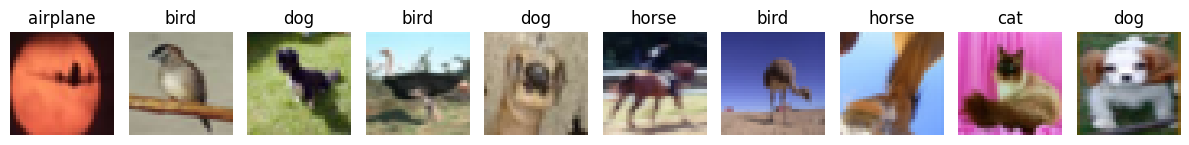

In [20]:
dataiter = iter(train_dataset_loader)
images, labels = next(dataiter)
class_names = train_dataset.classes
show_images = 10

fig, axes = plt.subplots(1, show_images, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    with torch.no_grad():
        image, label = images[i], labels[i]
        plt.sca(ax)
        imshow_tensor(image)
        ax.set_title(class_names[label])
plt.tight_layout()
plt.show()

### Neural Network Model

- A convolutional layer with 32 filters, a kernel size of 3, stride of 1, and padding of 1
- A max pooling layer with a kernel size of 2 and stride of 2.
- A Relu activation function.
- A convolutional layer with 64 filters, a kernel size of 3, stride of 1, and padding of 1
- A max pooling layer with a kernel size of 2 and stride of 2.
- A Relu activation function.
- A fully connected layer with 512 units and a Relu activation function.
- An output layer with 10 units (one for each class) and a log softmax activation function.

In [21]:
class ImagePredictorCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImagePredictorCNN, self).__init__()
        self.features = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            # Convolution output size = [(32 - 3 + 2*1) / 1 + 1] x [(32 - 3 + 2*1) / 1 + 1] x 32 = 32 x 32 x 32
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output size = [(32 - 2 + 2*0) / 2 + 1] x [(32 - 2 + 2*0) / 2 + 1] x 32 = 16 x 16 x 32
            nn.ReLU(),
            # Second convolutional layer
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            # Convolution output size = [(16 - 3 + 2*1) / 1 + 1] x [(16 - 3 + 2*1) / 1 + 1] x 64 = 16 x 16 x 64
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output size = [(16 - 2 + 2*0) / 2 + 1] x [(16 - 2 + 2*0) / 2 + 1] x 64 = 8 x 8 x 64
            nn.ReLU(),
            nn.Flatten(), # Flatten the output for the fully connected layer
            # Fully connected layer
            nn.Linear(in_features=8 * 8 * 64, out_features=num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        # return probabilities for each class with log-softmax
        return torch.log_softmax(x, dim=1)

> If we add padding of 1 to the convolutional layers, the output size will remain the same as the input size after the convolution operation. This is because padding adds extra pixels around the border of the input image, allowing the convolutional filter to fully cover the edges of the image. As a result, the spatial dimensions (height and width) of the output feature map will be equal to those of the input feature map.

> Stride determines how much the filter moves across the input image. A stride of 1 means the filter moves one pixel at a time, while a stride of 2 means it moves two pixels at a time. A larger stride results in a smaller output feature map, as the filter covers less area of the input image.


> Maxpooling is used to reduce the spatial dimensions of the feature maps, which helps to decrease the number of parameters and computations in the network. It also helps to make the model more robust to small translations and distortions in the input images by retaining only the most important features (maximum values) within each pooling window.

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [23]:
model = ImagePredictorCNN(num_classes=len(class_names))
model = model.to(device)
print(model)

ImagePredictorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=10, bias=True)
  )
)


### Optimizer and Loss function

In [24]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### Train, evaluation and loop functions

In [25]:
def train(model, device, train_loader, loss_fn, optimizer):
    model.train()  # set model to training mode

    # Initalize variables for the metrics
    epoch_loss = 0
    elements = 0
    correct_train = 0

    for i_batch, (image, label) in enumerate(train_loader):
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()  # zero the gradients

        # reshape is done to match the output shape of the model
        # we could also use squeeze on the model output
        predictions = model(image)  # forward pass
        loss = loss_fn(predictions, label)  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update weights

        # save metrics
        epoch_loss += loss.item()
        _, predicted = torch.max(predictions, 1) # takes the class with highest probability
        correct_train += (predicted == label).sum().item()
        elements += label.shape[0]

    # Calculate average loss and accuracy for the epoch
    loss_train = epoch_loss / i_batch
    accuracy_train = correct_train / elements

    return loss_train, accuracy_train

In [26]:
def evaluation(model, device, val_loader, loss_fn):
    model.eval()  # set model to evaluation mode

    # Initalize variables for the metrics
    epoch_loss = 0
    elements = 0
    correct_val = 0

    # we don't need gradients for validation, we just do forward pass
    with torch.no_grad():  # disable gradient computation
        for i_batch, (image, label) in enumerate(val_loader):
            image, label = image.to(device), label.to(device)

            predictions = model(image)  # forward pass

            loss = loss_fn(predictions, label)  # compute loss

            # save metrics
            epoch_loss += loss.item()
            _, predicted = torch.max(predictions, 1) # takes the class with highest probability
            correct_val += (predicted == label).sum().item()
            elements += label.shape[0] # length of the batch

    # Calculate average loss and accuracy for the epoch
    loss_val = epoch_loss / i_batch
    accuracy_val = correct_val / elements

    return loss_val, accuracy_val

In [27]:
def training_evaluation_loop(epochs, model, device, train_loader, val_loader, loss_fn, optimizer):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    total_time = 0

    for epoch in range(epochs):
        start_time = time.time()

        loss_train, accuracy_train = train(model, device, train_loader, loss_fn, optimizer)
        loss_val, accuracy_val = evaluation(model, device, val_loader, loss_fn)

        train_losses.append(loss_train)
        val_losses.append(loss_val)
        train_accuracies.append(accuracy_train)
        val_accuracies.append(accuracy_val)

        end_time = time.time()
        epoch_duration = end_time - start_time
        total_time += epoch_duration

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {loss_train:.4f}, Train Acc: {accuracy_train:.4f} - "
              f"Val Loss: {loss_val:.4f}, Val Acc: {accuracy_val:.4f} - "
              f"Time: {epoch_duration:.2f}s")
        
    print(f"Total training time: {total_time:.2f}s")

    return train_losses, val_losses, train_accuracies, val_accuracies

### Training the model

In [28]:
epochs = 10

train_losses, val_losses, train_accuracies, val_accuracies = training_evaluation_loop(
    epochs, model, device, train_dataset_loader, val_dataset_loader, loss_function, optimizer
)

Epoch 1/10 - Train Loss: 1.9377, Train Acc: 0.2803 - Val Loss: 1.7795, Val Acc: 0.3368 - Time: 33.51s
Epoch 2/10 - Train Loss: 1.8011, Train Acc: 0.3202 - Val Loss: 1.7349, Val Acc: 0.3612 - Time: 35.28s
Epoch 3/10 - Train Loss: 1.7435, Train Acc: 0.3459 - Val Loss: 1.6878, Val Acc: 0.3650 - Time: 34.52s
Epoch 4/10 - Train Loss: 1.7131, Train Acc: 0.3580 - Val Loss: 1.7189, Val Acc: 0.3770 - Time: 40.19s
Epoch 5/10 - Train Loss: 1.6882, Train Acc: 0.3683 - Val Loss: 1.6397, Val Acc: 0.3856 - Time: 36.06s
Epoch 6/10 - Train Loss: 1.6724, Train Acc: 0.3752 - Val Loss: 1.6495, Val Acc: 0.3874 - Time: 35.90s
Epoch 7/10 - Train Loss: 1.6607, Train Acc: 0.3843 - Val Loss: 1.5879, Val Acc: 0.4042 - Time: 34.56s
Epoch 8/10 - Train Loss: 1.6528, Train Acc: 0.3825 - Val Loss: 1.6156, Val Acc: 0.3999 - Time: 33.72s
Epoch 9/10 - Train Loss: 1.6382, Train Acc: 0.3928 - Val Loss: 1.6546, Val Acc: 0.3869 - Time: 35.58s
Epoch 10/10 - Train Loss: 1.6300, Train Acc: 0.3970 - Val Loss: 1.5558, Val Acc: 0

### Evaluation and results

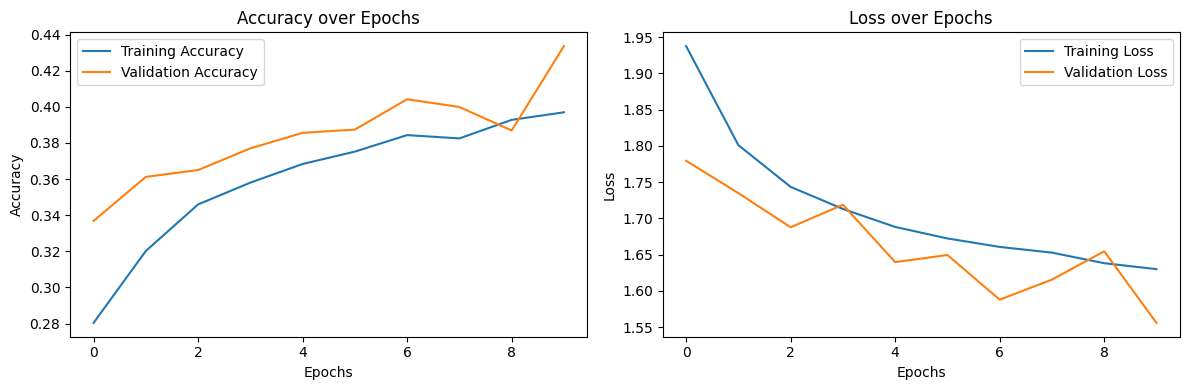

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(range(epochs), train_accuracies, label='Training Accuracy')
axes[0].plot(range(epochs), val_accuracies, label='Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

# Loss
axes[1].plot(range(epochs), train_losses, label='Training Loss')
axes[1].plot(range(epochs), val_losses, label='Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()


We only did 10 epochs because of time constraints, but the model can be trained for more epochs to achieve better performance. The training and validation accuracies can be further improved by tuning hyperparameters such as learning rate, batch size, and model architecture.